# Gathering data and preprocessing
## Dependencies and dataset imports

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

In [2]:
pd.set_option('display.max_columns',None)
df = pd.read_parquet("./Dataset/Flight_Delay.parquet")
df.reset_index(drop = True, inplace = True)

## Understanding given data

In [3]:
def describe_columns(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in givenDataFrame.columns:
        dtype = givenDataFrame[col].dtype
        unique_count = givenDataFrame[col].nunique(dropna=False)
        missing_count = givenDataFrame[col].isna().sum()
        top_values = givenDataFrame[col].value_counts(dropna=False).nlargest(3)

        summary.append({
            "column": col,
            "dtype": dtype,
            "unique_values": unique_count,
        })

    return pd.DataFrame(summary)

summary_df = describe_columns(df)
summary_df

,column,dtype,unique_values
0,Year,int64,6
1,Month,int64,12
2,DayofMonth,int64,31
3,FlightDate,str,1946
4,Marketing_Airline_Network,str,11
5,OriginCityName,str,382
6,DestCityName,str,382
7,CRSDepTime,int64,1426
8,DepTime,float64,1440
9,DepDelay,float64,2100


In [4]:
df.shape

(30132672, 29)

In [5]:
df['FlightDate']

0           2018-01-15
1           2018-01-16
2           2018-01-17
3           2018-01-18
4           2018-01-20
               ...    
30132667    2023-04-26
30132668    2023-04-26
30132669    2023-04-26
30132670    2023-04-26
30132671    2023-04-26
Name: FlightDate, Length: 30132672, dtype: str

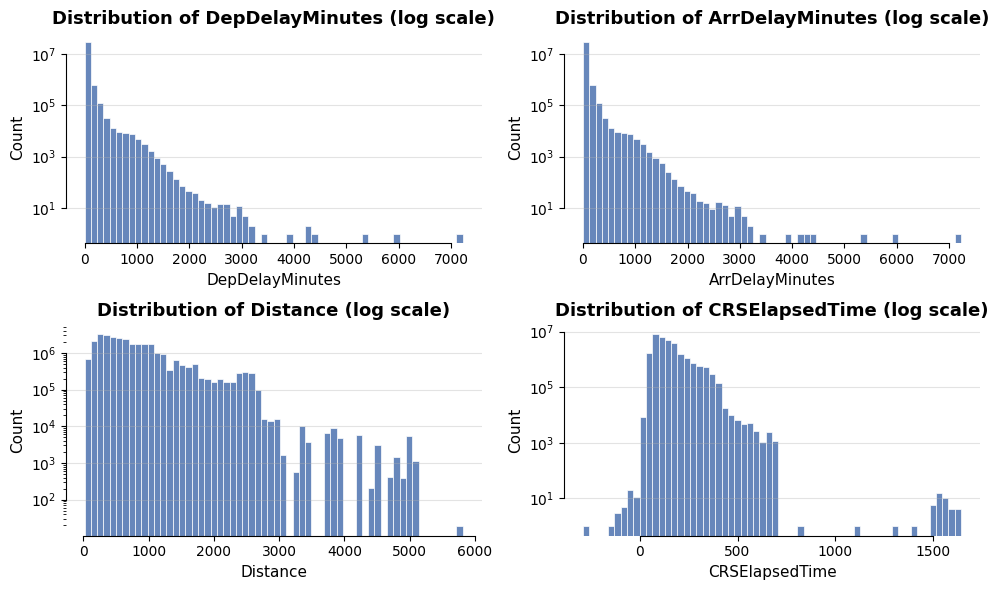

In [6]:
def plot_histogram_grid(
    givenDataFrame: pd.DataFrame,
    columns: list[str],
    ncols: int = 3,
    bins: int = 50,
    log_scale: bool = False,
    figsize: tuple[int, int] = (10, 6)
) -> None:
    ncols = max(1, ncols)
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(
            givenDataFrame[col].dropna(),
            bins=bins,
            kde=False,
            color="#4C72B0",
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85,
            ax=ax
        )
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        if log_scale:
            ax.set_yscale("log")
            ax.set_title(f"Distribution of {col} (log scale)", fontsize=13, weight="bold")
        ax.grid(axis="y", alpha=0.35)
    
    for empty_ax in axes[len(columns):]:
        empty_ax.axis("off")

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

plot_histogram_grid(
    df,
    columns=["DepDelayMinutes", "ArrDelayMinutes", "Distance", "CRSElapsedTime"],
    ncols=2,
    bins=60,
    log_scale=True,
    figsize=(10, 6)
)

Histograms suggest that data includes some extreme outliers (e.g., delays up to 7000 minutes ≈ multiple days), which is a perfect case study for imbalanced regression task.

Also, data anomalies detected (scheduled flight time with negative values)

In [7]:
df['Marketing_Airline_Network'].unique()

<ArrowStringArray>
['UA', 'DL', 'F9', 'NK', 'AA', 'WN', 'AS', 'HA', 'VX', 'B6', 'G4']
Length: 11, dtype: str

In [8]:
df['OriginCityName']

0              Newark, NJ
1              Newark, NJ
2              Newark, NJ
3              Newark, NJ
4              Newark, NJ
                ...      
30132667      Houston, TX
30132668      Chicago, IL
30132669    Las Vegas, NV
30132670        Miami, FL
30132671        Tampa, FL
Name: OriginCityName, Length: 30132672, dtype: str

OriginCityName contains information about both city and state, for the purposes of this analysis it's better to keep them separated.

### Memory usage

In [9]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

8.14 GB


In [10]:
df.memory_usage(deep=True).sort_values(ascending=False) / 1e6  # MB per column

OriginCityName               636.434308
DestCityName                 636.234861
FlightDate                   542.388096
Marketing_Airline_Network    301.326720
TaxiIn                       241.061376
Distance                     241.061376
ArrDelayMinutes              241.061376
CRSElapsedTime               241.061376
ActualElapsedTime            241.061376
AirTime                      241.061376
WeatherDelay                 241.061376
DistanceGroup                241.061376
CarrierDelay                 241.061376
ArrTime                      241.061376
NASDelay                     241.061376
SecurityDelay                241.061376
ArrDelay                     241.061376
LateAircraftDelay            241.061376
CRSArrTime                   241.061376
Year                         241.061376
WheelsOn                     241.061376
WheelsOff                    241.061376
TaxiOut                      241.061376
DepDelayMinutes              241.061376
DepDelay                     241.061376


### Checking for missing data

In [11]:
def printMissingDataSummary(givenDataFrame: pd.DataFrame) -> None:
    missingCount = givenDataFrame.isna().sum()
    missingPercentage = (missingCount / len(givenDataFrame) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(df)


Missing data summary:
                           missingCount  missingPercentage
Year                                  0                0.0
Month                                 0                0.0
DayofMonth                            0                0.0
FlightDate                            0                0.0
Marketing_Airline_Network             0                0.0
OriginCityName                        0                0.0
DestCityName                          0                0.0
CRSDepTime                            0                0.0
DepTime                               0                0.0
DepDelay                              0                0.0
DepDelayMinutes                       0                0.0
TaxiOut                               0                0.0
WheelsOff                             0                0.0
WheelsOn                              0                0.0
TaxiIn                                0                0.0
CRSArrTime                       

In [12]:
df.describe()

,Year,Month,DayofMonth,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07,3.013267e+07
mean,2.020091e+03,6.297564e+00,1.572297e+01,1.322736e+03,1.327245e+03,1.061144e+01,1.429690e+01,1.650212e+01,1.350119e+03,1.456780e+03,7.453306e+00,1.485342e+03,1.462064e+03,3.754417e+00,1.443629e+01,1.388678e+02,1.320092e+02,1.080538e+02,7.764743e+02,3.580303e+00,5.050473e+00,8.417200e-01,2.994112e+00,2.741088e-02,5.522570e+00
std,1.602171e+00,3.487835e+00,8.770224e+00,4.840125e+02,4.983890e+02,5.198293e+01,5.081470e+01,9.467169e+00,4.998794e+02,5.249568e+02,6.024017e+00,5.081119e+02,5.286442e+02,5.454628e+01,5.072644e+01,7.096150e+01,7.061227e+01,6.872621e+01,5.823315e+02,2.291205e+00,3.370024e+01,1.509353e+01,1.664252e+01,1.650743e+00,2.751737e+01
min,2.018000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-3.420000e+02,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-1.290000e+03,0.000000e+00,-2.920000e+02,4.000000e+00,-1.412000e+03,1.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.019000e+03,3.000000e+00,8.000000e+00,9.150000e+02,9.160000e+02,-6.000000e+00,0.000000e+00,1.100000e+01,9.310000e+02,1.046000e+03,4.000000e+00,1.105000e+03,1.050000e+03,-1.700000e+01,0.000000e+00,8.800000e+01,8.100000e+01,5.800000e+01,3.520000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.020000e+03,6.000000e+00,1.600000e+01,1.315000e+03,1.320000e+03,-3.000000e+00,0.000000e+00,1.400000e+01,1.333000e+03,1.456000e+03,6.000000e+00,1.510000e+03,1.500000e+03,-9.000000e+00,0.000000e+00,1.200000e+02,1.140000e+02,9.000000e+01,6.200000e+02,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.022000e+03,9.000000e+00,2.300000e+01,1.729000e+03,1.737000e+03,3.000000e+00,3.000000e+00,1.900000e+01,1.751000e+03,1.903000e+03,9.000000e+00,1.914000e+03,1.909000e+03,-1.000000e+00,0.000000e+00,1.690000e+02,1.620000e+02,1.370000e+02,1.011000e+03,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.023000e+03,1.200000e+01,3.100000e+01,2.359000e+03,2.400000e+03,7.223000e+03,7.223000e+03,1.439000e+03,2.400000e+03,2.400000e+03,1.082000e+03,2.400000e+03,2.400000e+03,7.232000e+03,7.232000e+03,1.645000e+03,1.604000e+03,1.557000e+03,5.812000e+03,1.100000e+01,7.232000e+03,2.900000e+03,1.848000e+03,1.460000e+03,2.962000e+03


### Checking for duplicates

In [13]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of           Year  Month  DayofMonth  FlightDate Marketing_Airline_Network  \
0         2018      1          15  2018-01-15                        UA   
1         2018      1          16  2018-01-16                        UA   
2         2018      1          17  2018-01-17                        UA   
3         2018      1          18  2018-01-18                        UA   
4         2018      1          20  2018-01-20                        UA   
...        ...    ...         ...         ...                       ...   
30132667  2023      4          26  2023-04-26                        UA   
30132668  2023      4          26  2023-04-26                        UA   
30132669  2023      4          26  2023-04-26                        UA   
30132670  2023      4          26  2023-04-26                        UA   
30132671  2023      4          26  2023-04-26                        UA   

         OriginCityName       DestCityName  CRSDepTime  

### Memory savings

In [14]:
for col in df.select_dtypes(include=['int', 'int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [15]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

4.68 GB


## Column operations

### Sanity check #1

In [16]:
df["speed"] = (df["Distance"] * 1.609344) / (df["ActualElapsedTime"] / 60)
df['speed'].nlargest(100)
df = df[df['speed'] <= 1000]
df.drop('speed', axis=1, inplace=True)


Limiting max speed of Aircrafts to 1000 km / h. Dropping rows with exceeding values.

### Dealing with dates

In [17]:
# Converting Flightdate to datetime format
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# Creating new column with day of the week
df["DayofWeek"] = df["FlightDate"].dt.day_of_week

# Creating new column for Holidays
cal = calendar()
holidays = cal.holidays(start=df["FlightDate"].min(), end=df["FlightDate"].max())
df["Holidays"] = df["FlightDate"].isin(holidays)

df.drop(['FlightDate'], axis=1, inplace=True)
# If we know the actual values then what's the point of training?
df.drop(['DepTime', 'ArrTime'], axis=1, inplace=True)
# keeping only scheduled times, since they are known before the flight and can be used for prediction

### Time formatting

In [18]:
def hhmm_to_minutes(series):
    series = series.fillna(0).astype(int)
    hours = series // 100
    minutes = series % 100
    return hours * 60 + minutes

df["scheduledDepartureMinutes"] = hhmm_to_minutes(df["CRSDepTime"])
df["scheduledArrivalMinutes"] = hhmm_to_minutes(df["CRSArrTime"])

In [19]:
df.drop(['CRSDepTime', 'CRSArrTime'], axis=1, inplace=True)
df.rename(columns={"scheduledDepartureMinutes": "scheduledDepartureTime",
                   "scheduledArrivalMinutes": "scheduledArrivalTime"}, inplace=True)

In [20]:
df['scheduledDeparture_sin'] = np.sin(2 * np.pi * df['scheduledDepartureTime'] / 1440)
df['scheduledDeparture_cos'] = np.cos(2 * np.pi * df['scheduledDepartureTime'] / 1440)
df['scheduledArrival_sin'] = np.sin(2 * np.pi * df['scheduledArrivalTime'] / 1440)
df['scheduledArrival_cos'] = np.cos(2 * np.pi * df['scheduledArrivalTime'] / 1440)

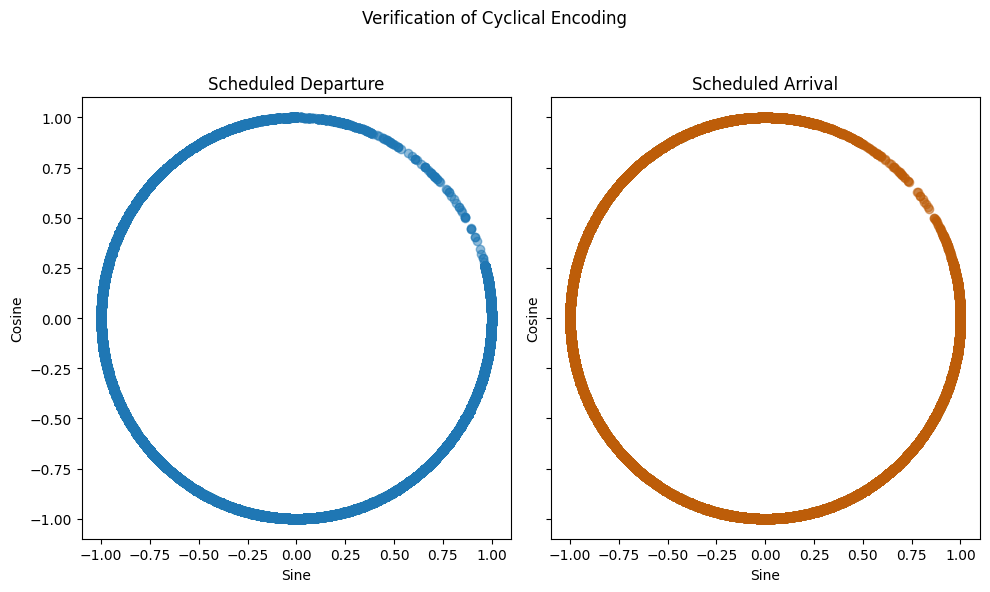

In [21]:
sample_df = df.sample(100000)

departure_color = '#1f77b4'
arrival_color = "#bd5d09"

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)
axes[0].scatter(sample_df['scheduledDeparture_sin'], sample_df['scheduledDeparture_cos'], alpha=0.5, color=departure_color)
axes[0].set_title("Scheduled Departure")
axes[0].set_xlabel("Sine")
axes[0].set_ylabel("Cosine")

axes[1].scatter(sample_df['scheduledArrival_sin'], sample_df['scheduledArrival_cos'], alpha=0.5, color=arrival_color)
axes[1].set_title("Scheduled Arrival")
axes[1].set_xlabel("Sine")
axes[1].set_ylabel("Cosine")

fig.suptitle("Verification of Cyclical Encoding")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Sanity check #2

In [22]:
# checking for negative values in CRSElapsedTime
df = df[df['CRSElapsedTime'] >= 0]

Removed rows where scheduled air time is negative. 

### Identify Time zone changes

In [23]:
def compute_timezone_shift(dep_min, arr_min, elapsed):
    # observed elapsed time (handles midnight)
    observed = (arr_min - dep_min) % 1440
    
    # raw timezone offset in minutes
    tz_offset = observed - elapsed
    
    # snap to nearest full hour (in minutes)
    tz_shift = (tz_offset / 60).round() * 60
    
    return tz_shift.astype("Int16")

In [24]:
df["timeZoneShift"] = compute_timezone_shift(
    df["scheduledDepartureTime"],
    df["scheduledArrivalTime"],
    df["CRSElapsedTime"]
)

In [25]:
print(df["timeZoneShift"].value_counts().sort_index().head(30))
df["timeZoneShift"] = pd.to_numeric(df["timeZoneShift"], downcast='integer')

timeZoneShift
-1500           9
-1440          25
-1380           4
-1320           1
-1260           1
-1080           1
-960            1
-720            1
-600            1
-540            1
-420            8
-360         3741
-300         9073
-240        11429
-180       894341
-120      1362373
-60       4577421
0        16342596
60        4626609
120       1358358
180        885447
240         12585
300          9313
360          3694
420            12
960             1
1020            1
1080            1
1200            2
1260            2
Name: count, dtype: Int64


### Unused columns

In [26]:
# ArrDelay is the same as ArrDelayMinutes
df.drop(['ArrDelay'], axis = 1, inplace = True)

# DepDelay is the same as DepDelayMinutes
df.drop(['DepDelay'], axis = 1, inplace = True)

# WheelsOff contins same information as DepTime
df.drop(['WheelsOff'], axis = 1, inplace = True)

# WheelsOn contins same information as ArrTime
df.drop(['WheelsOn'], axis = 1, inplace = True)

# WheelsOff contins same information as DepTime
df.drop(['TaxiOut'], axis = 1, inplace = True)

# WheelsOn contins same information as ArrTime
df.drop(['TaxiIn'], axis = 1, inplace = True)

# AirTime is the same as ActualElapsedTime
df.drop(['AirTime'], axis = 1, inplace = True)

# ActualElapsedTime contains information about the future
df.drop(['ActualElapsedTime'], axis = 1, inplace = True)

# Distance group is unncessary, since we have the actual Distance column
df.drop(['DistanceGroup'], axis = 1, inplace = True)

# After cyclis encoding, the original time columns are no longer needed
df.drop(['scheduledDepartureTime'], axis = 1, inplace = True)
df.drop(['scheduledArrivalTime'], axis = 1, inplace = True)

### Separating Cities from States

In [27]:
# Splitting OriginCityName
df[['OriginCity', 'OriginState']] = df['OriginCityName'].str.split(', ', expand = True)

# Splitting DestCityName
df[['DestCity','DestState']] = df['DestCityName'].str.split(', ', expand = True)

# Dropping the original columns
df.drop(['OriginCityName', 'DestCityName'], axis = 1, inplace = True)

df[['OriginCity', 'OriginState', 'DestCity', 'DestState']]

,OriginCity,OriginState,DestCity,DestState
0,Newark,NJ,Charleston,SC
1,Newark,NJ,Charleston,SC
2,Newark,NJ,Charleston,SC
3,Newark,NJ,Charleston,SC
4,Newark,NJ,Charleston,SC
...,...,...,...,...
30132667,Houston,TX,San Francisco,CA
30132668,Chicago,IL,Philadelphia,PA
30132669,Las Vegas,NV,Chicago,IL
30132670,Miami,FL,Newark,NJ


### Remapping airline names

In [28]:
df.loc[df['Marketing_Airline_Network'] == 'UA', 'CarrierName'] = 'United Airlines'
df.loc[df['Marketing_Airline_Network'] == 'DL', 'CarrierName'] = 'Delta Airlines'
df.loc[df['Marketing_Airline_Network'] == 'F9', 'CarrierName'] = 'Frontier Airlines'
df.loc[df['Marketing_Airline_Network'] == 'NK', 'CarrierName'] = 'Spirit Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AA', 'CarrierName'] = 'American Airlines'
df.loc[df['Marketing_Airline_Network'] == 'WN', 'CarrierName'] = 'Southwest Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AS', 'CarrierName'] = 'Alaska Airlines'
df.loc[df['Marketing_Airline_Network'] == 'HA', 'CarrierName'] = 'Hawaiian Airlines'
df.loc[df['Marketing_Airline_Network'] == 'VX', 'CarrierName'] = 'Virgin America'
df.loc[df['Marketing_Airline_Network'] == 'B6', 'CarrierName'] = 'JetBlue Airways'
df.loc[df['Marketing_Airline_Network'] == 'G4', 'CarrierName'] = 'Allegiant Air'

df['CarrierName'].unique()
df.drop(['Marketing_Airline_Network'], axis = 1, inplace = True)

### Renaming columns to camelCase

In [29]:
df.rename(columns={"DepTime": "departureTime",
                   "DepDelayMinutes": "departureDelay",
                   "TaxiIn": "taxiIn",
                   "TaxiOut": "taxiOut",
                   "ArrTime": "arrivalTime",
                   "ArrDelayMinutes": "arrivalDelay",
                   "ActualElapsedTime": "airTime",
                   "Distance": "distance",
                   "CarrierDelay": "carrierDelay",
                   "WeatherDelay": "weatherDelay",
                   "NASDelay": "nasDelay",
                   "SecurityDelay": "securityDelay",
                   "LateAircraftDelay": "lateAircraftDelay",
                   "DayofWeek": "dayOfWeek",
                   "Holidays": "isHoliday",
                   "OriginCity": "originCity",
                   "OriginState": "originState",
                   "DestCity": "destCity",
                   "DestState": "destState",
                   "CarrierName": "carrierName",
                   "CRSDepTime": "scheduledDepartureTime",
                   "CRSArrTime": "scheduledArrivalTime",
                   "CRSElapsedTime": "scheduledAirTime",
                   "Year": "year",
                   "Month": "month",
                   "DayofMonth": "dayOfMonth",
                   "DayofWeek": "dayOfWeek"
                   }, inplace=True)

### Target Variable

Since our goal is to create an imbalanced regresssion model for delay its best to understand the differences between the types of delay present in this dataset. Delays explained:

`departureDelay` → Total departure delay (in minutes)

`arrivalDelay` → Total arrival delay (in minutes)

`carrierDelay` → airline-related issues (crew, maintenance, etc.)

`weatherDelay` → bad weather

`nasDelay` → air traffic control / airport system issues

`securityDelay` → security-related delays

`lateAircraftDelay` → previous flight was late (domino effect)

In this analysis the target variable to base our regression model on is the `arrivalDelay` column. Due to this choice, we need to additionally drop all the aforementioned columns, as they include after-the-fact knowledge about flight delays. This is done in order to prevent data leakage during training.

### Dropping even more columns

In [30]:
df.drop(['departureDelay'], axis = 1, inplace = True)
df.drop(['carrierDelay'], axis = 1, inplace = True)
df.drop(['weatherDelay'], axis = 1, inplace = True)
df.drop(['nasDelay'], axis = 1, inplace = True)
df.drop(['securityDelay'], axis = 1, inplace = True)
df.drop(['lateAircraftDelay'], axis = 1, inplace = True)

### Dealing with categoricals

In [31]:
categorical_cols = ['originCity', 'originState', 'destCity', 'destState', 'carrierName']

print("Categorical features memory usage:\n")
print(f"Before conversion: {df[categorical_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")

for col in categorical_cols:
    df[col] = df[col].astype('category')

print(f"After conversion: {df[categorical_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Categorical features memory usage:

Before conversion: 2473.42 MB
After conversion: 431.06 MB


### Predictors
`scheduledDepartureTime`, `scheduledArrivalTime`, `scheduledAirTime`, `year`, `month`, `dayOfMonth`, `distance`, `dayOfWeek`, `isHoliday`, `originCity`, `originState`, `destinationCity`, `destinationState`, `carrierName`

### Column state after initial processing

In [32]:
describe_columns(df)

,column,dtype,unique_values
0,year,int16,6
1,month,int8,12
2,dayOfMonth,int8,31
3,arrivalDelay,float32,1974
4,scheduledAirTime,float32,698
5,distance,float32,1752
6,dayOfWeek,int32,7
7,isHoliday,bool,2
8,scheduledDeparture_sin,float64,1271
9,scheduledDeparture_cos,float64,1293


# Imbalanced Preprocessing

# Modelling and Evaluation

---
### EVERYTHING BELOW THIS SHOULD BE DONE AFTER SPLIT TO AVOID DATA LEAKS
---

### Relevance function (change to train data only)

In [33]:
# df["phi"] = df["arrivalDelay"].rank(pct=True)

We chose the rank based, imbalance-aware relevance function, formally:
\begin{align*}
\Phi{x_i} & = \frac{rank\left(x_i\right)}{N}\\
\end{align*}
This way, the model will focus on relative importance instead of absolute units and retain the significance of the tail-end.

### Target encoding with smoothing (change to train data only)